## Setup & Imports

In [1]:
# Standard libraries
import sys
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Add project to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

# Import FairXAI modules
from fairxai.data.loaders import CardiacDataLoader
from fairxai.data.profilers import DataProfiler
from fairxai.fairness.metrics import FairnessMetrics, summarize_fairness_results
from fairxai.visualization.plots import (
    plot_dataset_characteristics,
    plot_preprocessing_fairness,
    plot_feature_importance,
    plot_confusion_matrices,
    plot_fairness_heatmap,
    plot_train_test_comparison,
    plot_equalized_odds_details,
    plot_calibration_by_group,
    plot_fairness_evolution
)

print(f"Project root: {project_root}")

Project root: /home/miguel/Desktop/Dissertacao/Code/FairXAI


## 1. Data Loading & Initial Exploration

Load the standardized cardiac datasets and examine their structure.

In [2]:
# Paths
data_raw_cardiac = project_root / 'data/raw/cardiac'
data_processed_cardiac = project_root / 'data/processed/cardiac'
results_fairness = project_root / 'results/cardiac/fairness'
baseline_results = project_root / 'experiments/cardiac/baseline'

# Load standardized datasets
cleveland_raw = pd.read_csv(data_raw_cardiac / 'cleveland_standardized.csv')
kaggle_raw = pd.read_csv(data_raw_cardiac / 'kaggle_heart_standardized.csv')

print("Cleveland Dataset:")
print(f"  Shape: {cleveland_raw.shape}")
print(f"  Features: {cleveland_raw.shape[1]}")
print(f"  Target distribution: {cleveland_raw['heart_disease'].value_counts().to_dict()}")
print(f"  Age groups: {cleveland_raw['age_group'].value_counts().to_dict()}")
print(f"  Sex: {cleveland_raw['sex'].value_counts().to_dict()}")

print("\nKaggle Heart Dataset:")
print(f"  Shape: {kaggle_raw.shape}")
print(f"  Features: {kaggle_raw.shape[1]}")
print(f"  Target distribution: {kaggle_raw['heart_disease'].value_counts().to_dict()}")
print(f"  Age groups: {kaggle_raw['age_group'].value_counts().to_dict()}")
print(f"  Sex: {kaggle_raw['sex'].value_counts().to_dict()}")

Cleveland Dataset:
  Shape: (297, 18)
  Features: 18
  Target distribution: {0: 160, 1: 137}
  Age groups: {'50-59': 126, '40-49': 75, '60-69': 73, '<40': 17, '70+': 6}
  Sex: {'Male': 201, 'Female': 96}

Kaggle Heart Dataset:
  Shape: (918, 17)
  Features: 17
  Target distribution: {1: 508, 0: 410}
  Age groups: {'50-59': 381, '40-49': 223, '60-69': 197, '<40': 93, '70+': 24}
  Sex: {'Male': 725, 'Female': 193}


### Visualize Dataset Characteristics

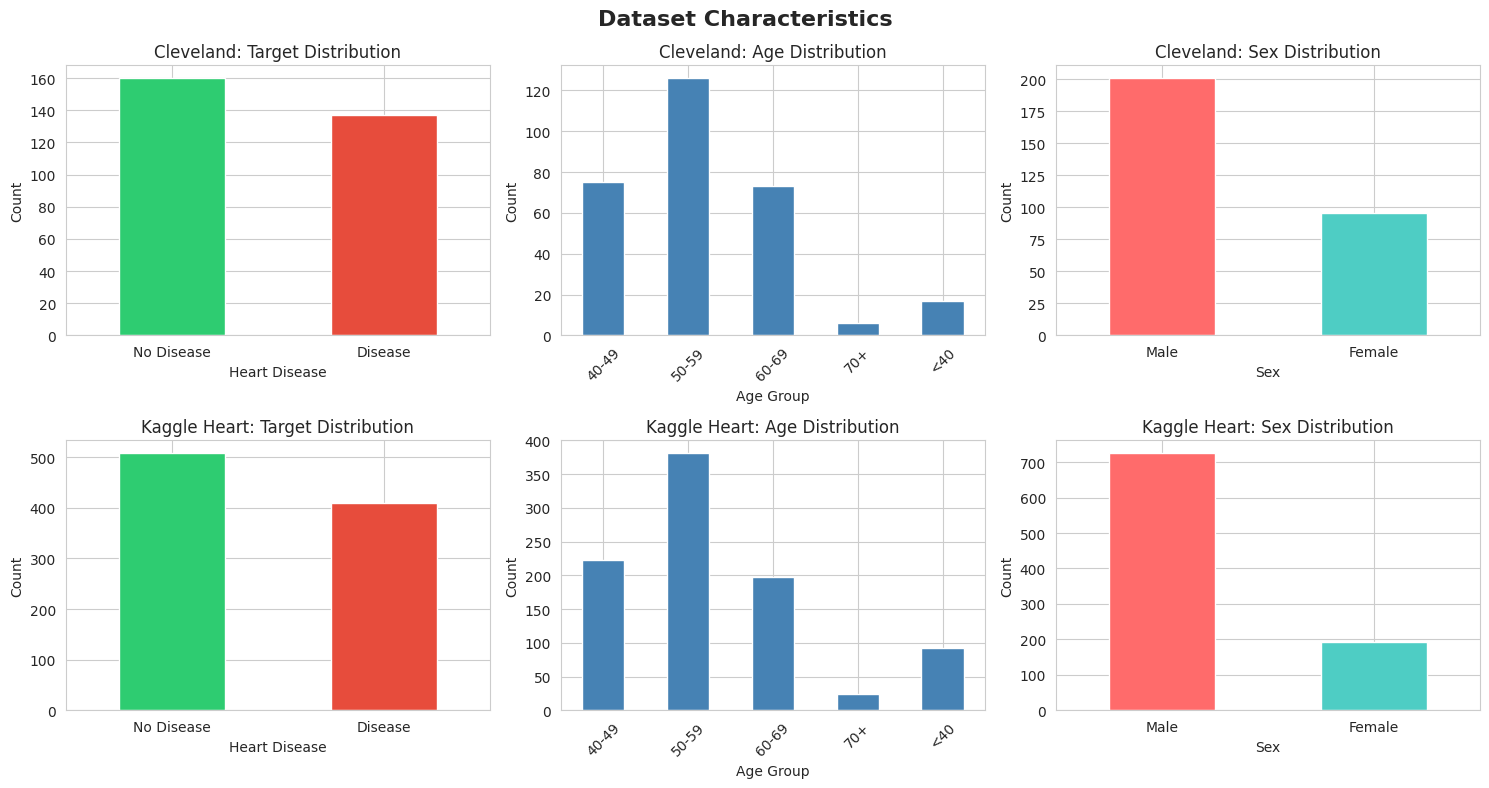

In [3]:
# Use the reusable plotting function
datasets = {
    'Cleveland': cleveland_raw,
    'Kaggle Heart': kaggle_raw
}

plot_dataset_characteristics(datasets)
plt.show()

## 2. Pre-Processing Fairness Assessment

Examine fairness issues in the raw data before any processing.

In [4]:
# Load pre-processing fairness profiles
with open(results_fairness / 'cleveland_data_profile.json', 'r') as f:
    cleveland_profile = json.load(f)

with open(results_fairness / 'kaggle_heart_data_profile.json', 'r') as f:
    kaggle_profile = json.load(f)

print("Cleveland Pre-Processing Fairness:")
print(f"  Disease prevalence: {cleveland_profile['basic_stats']['target_prevalence']:.2%}")
print(f"  Age group representation balance (CV): {cleveland_profile['representation_balance']['age_group']['coefficient_of_variation']:.3f}")
print(f"  Age group max statistical parity diff: {cleveland_profile['label_imbalance_by_group']['age_group']['statistical_parity_difference']['max_difference']:.2%}")
print(f"  Sex max statistical parity diff: {cleveland_profile['label_imbalance_by_group']['sex']['statistical_parity_difference']['max_difference']:.2%}")

print("\nKaggle Heart Pre-Processing Fairness:")
print(f"  Disease prevalence: {kaggle_profile['basic_stats']['target_prevalence']:.2%}")
print(f"  Age group representation balance (CV): {kaggle_profile['representation_balance']['age_group']['coefficient_of_variation']:.3f}")
print(f"  Age group max statistical parity diff: {kaggle_profile['label_imbalance_by_group']['age_group']['statistical_parity_difference']['max_difference']:.2%}")
print(f"  Sex max statistical parity diff: {kaggle_profile['label_imbalance_by_group']['sex']['statistical_parity_difference']['max_difference']:.2%}")

Cleveland Pre-Processing Fairness:
  Disease prevalence: 46.13%
  Age group representation balance (CV): 0.821
  Age group max statistical parity diff: 42.24%
  Sex max statistical parity diff: 29.68%

Kaggle Heart Pre-Processing Fairness:
  Disease prevalence: 55.34%
  Age group representation balance (CV): 0.743
  Age group max statistical parity diff: 39.20%
  Sex max statistical parity diff: 37.27%


### Visualize Pre-Processing Fairness Violations

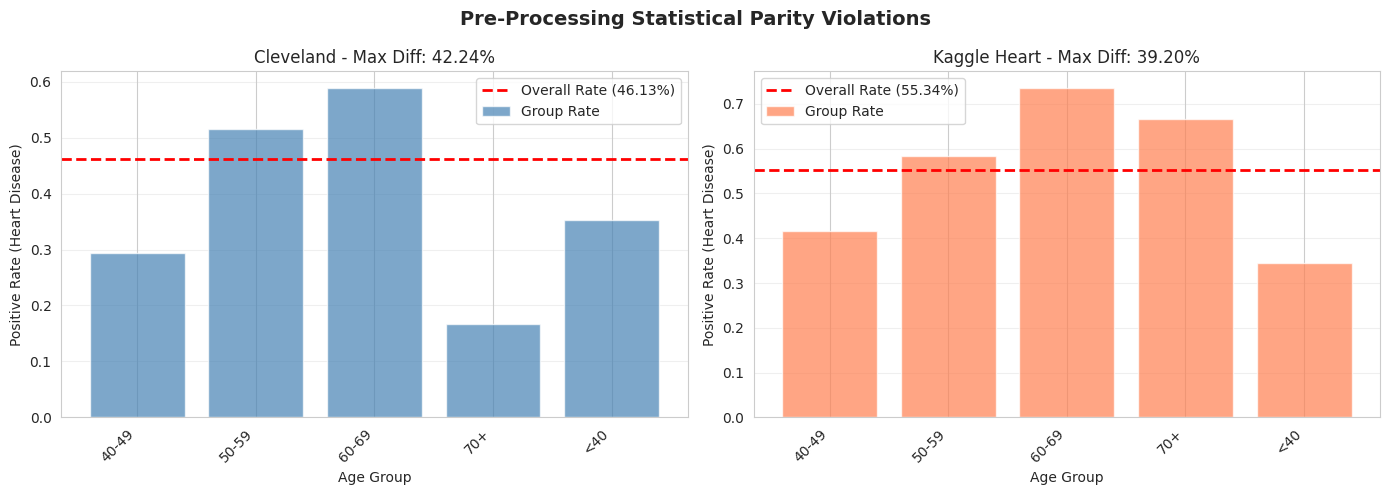

In [5]:
# Use the reusable plotting function
profiles = {
    'cleveland': cleveland_profile,
    'kaggle': kaggle_profile
}

plot_preprocessing_fairness(profiles, dataset_names=['Cleveland', 'Kaggle Heart'])
plt.show()

## 3. Model Training Results

Load and visualize baseline logistic regression performance.

In [6]:
# Load training results
with open(baseline_results / 'training_results.json', 'r') as f:
    training_results = json.load(f)

# Display performance metrics
print("Model Performance Summary:")
print("="*60)

for dataset_name, results in training_results.items():
    print(f"\n{dataset_name.upper()}:")
    test_metrics = results['test_metrics']
    print(f"  Accuracy:  {test_metrics['accuracy']:.3f}")
    print(f"  Precision: {test_metrics['precision']:.3f}")
    print(f"  Recall:    {test_metrics['recall']:.3f}")
    print(f"  F1 Score:  {test_metrics['f1_score']:.3f}")
    print(f"  AUC-ROC:   {test_metrics['auc_roc']:.3f}")

Model Performance Summary:

CLEVELAND:
  Accuracy:  0.798
  Precision: 0.780
  Recall:    0.780
  F1 Score:  0.780
  AUC-ROC:   0.886

KAGGLE_HEART:
  Accuracy:  0.851
  Precision: 0.858
  Recall:    0.875
  F1 Score:  0.866
  AUC-ROC:   0.913


### Feature Importance Analysis

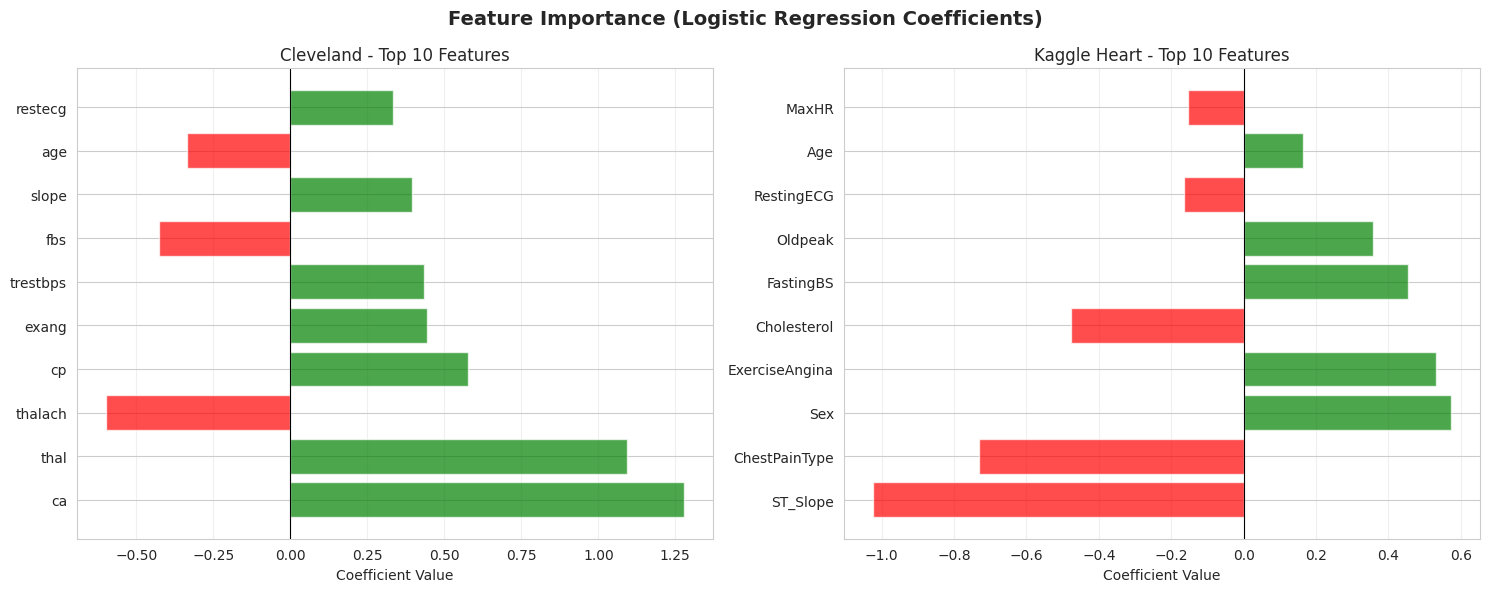

In [7]:
# Load feature importance
cleveland_importance = pd.read_csv(baseline_results / 'cleveland_feature_importance.csv')
kaggle_importance = pd.read_csv(baseline_results / 'kaggle_heart_feature_importance.csv')

# Use the reusable plotting function
importance_dfs = {
    'Cleveland': cleveland_importance,
    'Kaggle Heart': kaggle_importance
}

plot_feature_importance(importance_dfs, top_n=10)
plt.show()

### Confusion Matrix Visualization

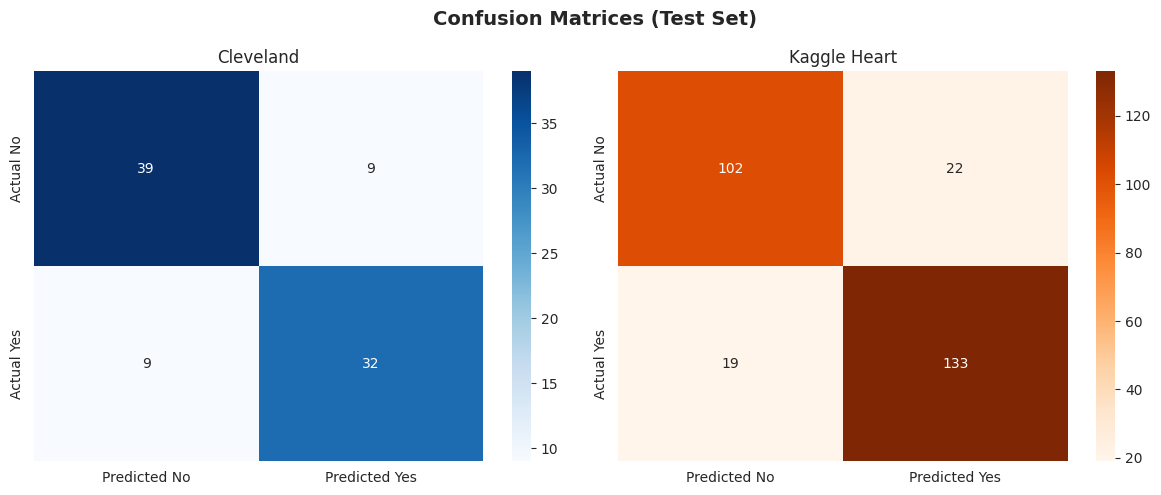

In [8]:
# Use the reusable plotting function
plot_confusion_matrices(training_results, dataset_names=['Cleveland', 'Kaggle Heart'])
plt.show()

## 4. Post-Prediction Fairness Assessment

Comprehensive evaluation of fairness in model predictions.

In [9]:
# Load fairness assessment results
with open(results_fairness / 'cleveland_fairness_assessment.json', 'r') as f:
    cleveland_fairness = json.load(f)

with open(results_fairness / 'kaggle_heart_fairness_assessment.json', 'r') as f:
    kaggle_fairness = json.load(f)

# Load summary tables
cleveland_summary = pd.read_csv(results_fairness / 'cleveland_fairness_summary.csv')
kaggle_summary = pd.read_csv(results_fairness / 'kaggle_heart_fairness_summary.csv')

print("Fairness Assessment Summary Loaded")
print(f"Cleveland metrics: {len(cleveland_summary)} entries")
print(f"Kaggle metrics: {len(kaggle_summary)} entries")

Fairness Assessment Summary Loaded
Cleveland metrics: 16 entries
Kaggle metrics: 16 entries


### Fairness Metrics Heatmap

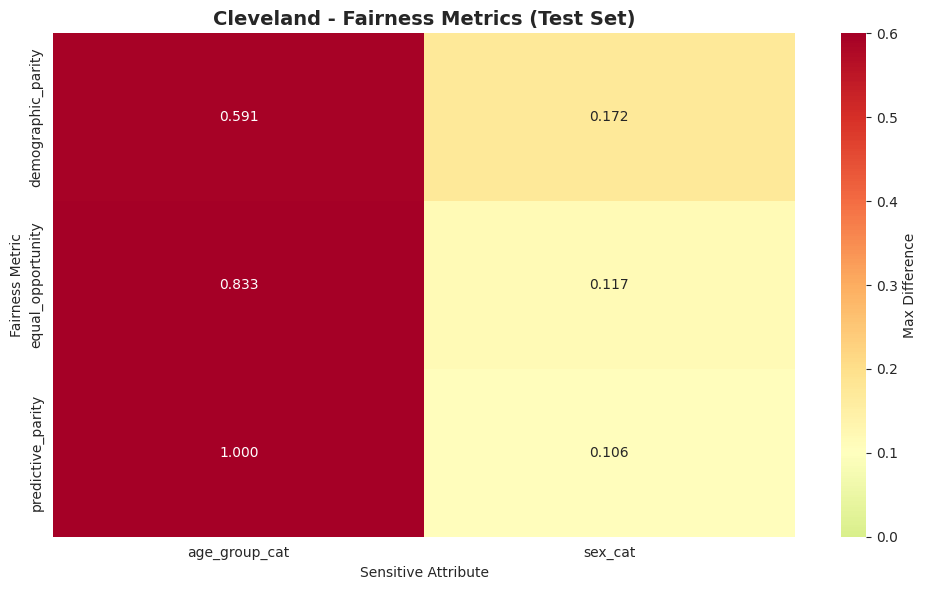

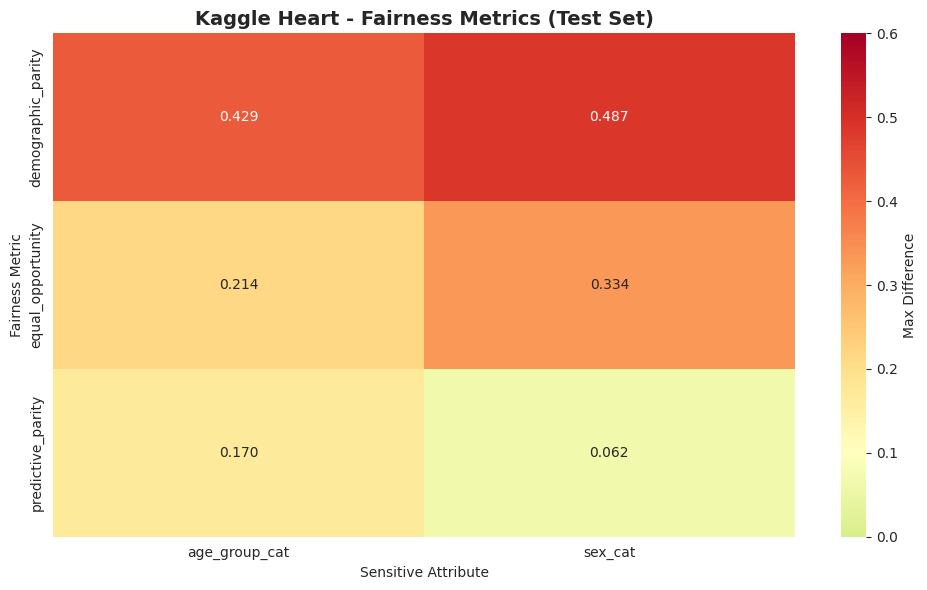

In [10]:
# Use the reusable plotting function
plot_fairness_heatmap(cleveland_summary, 'Cleveland')
plot_fairness_heatmap(kaggle_summary, 'Kaggle Heart')
plt.show()

### Group Fairness Comparison: Train vs Test

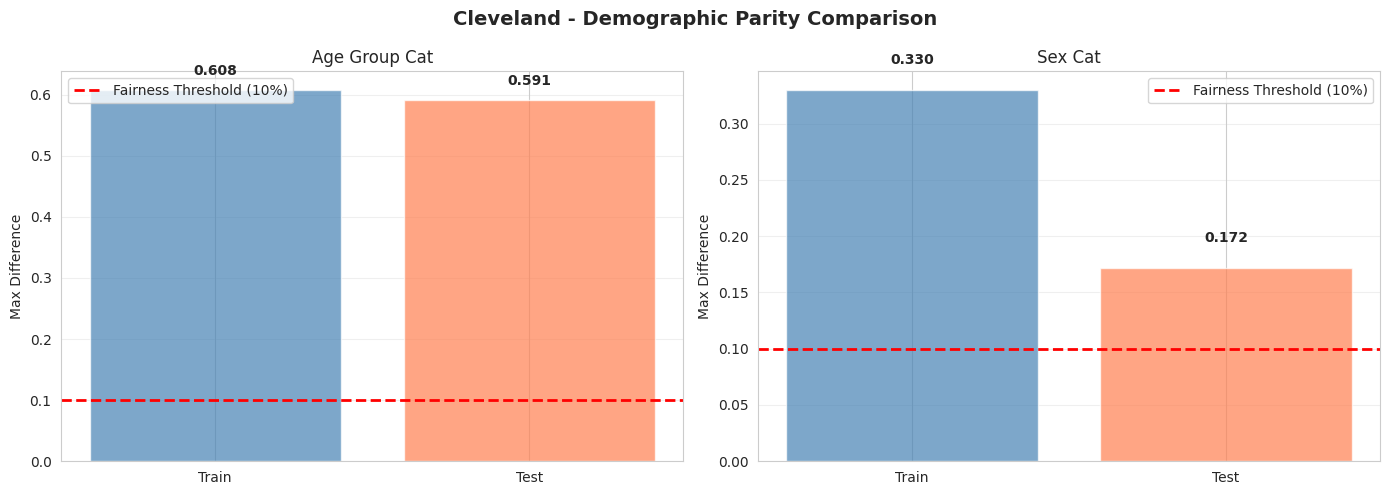

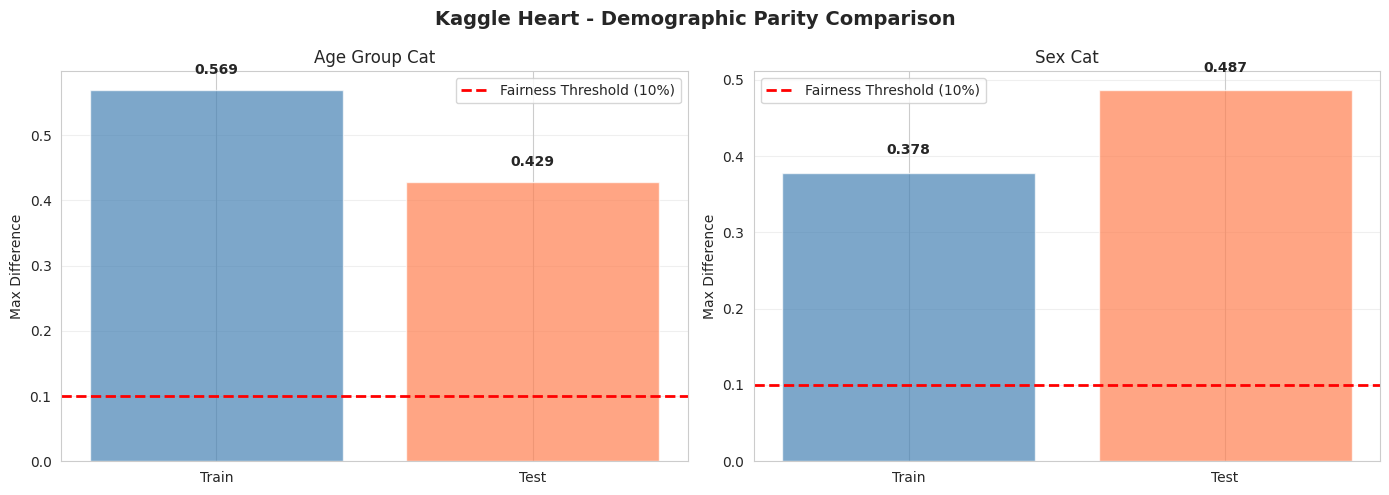

In [11]:
# Use the reusable plotting function
plot_train_test_comparison(cleveland_summary, 'Cleveland', 'demographic_parity')
plot_train_test_comparison(kaggle_summary, 'Kaggle Heart', 'demographic_parity')
plt.show()

### Equalized Odds Visualization

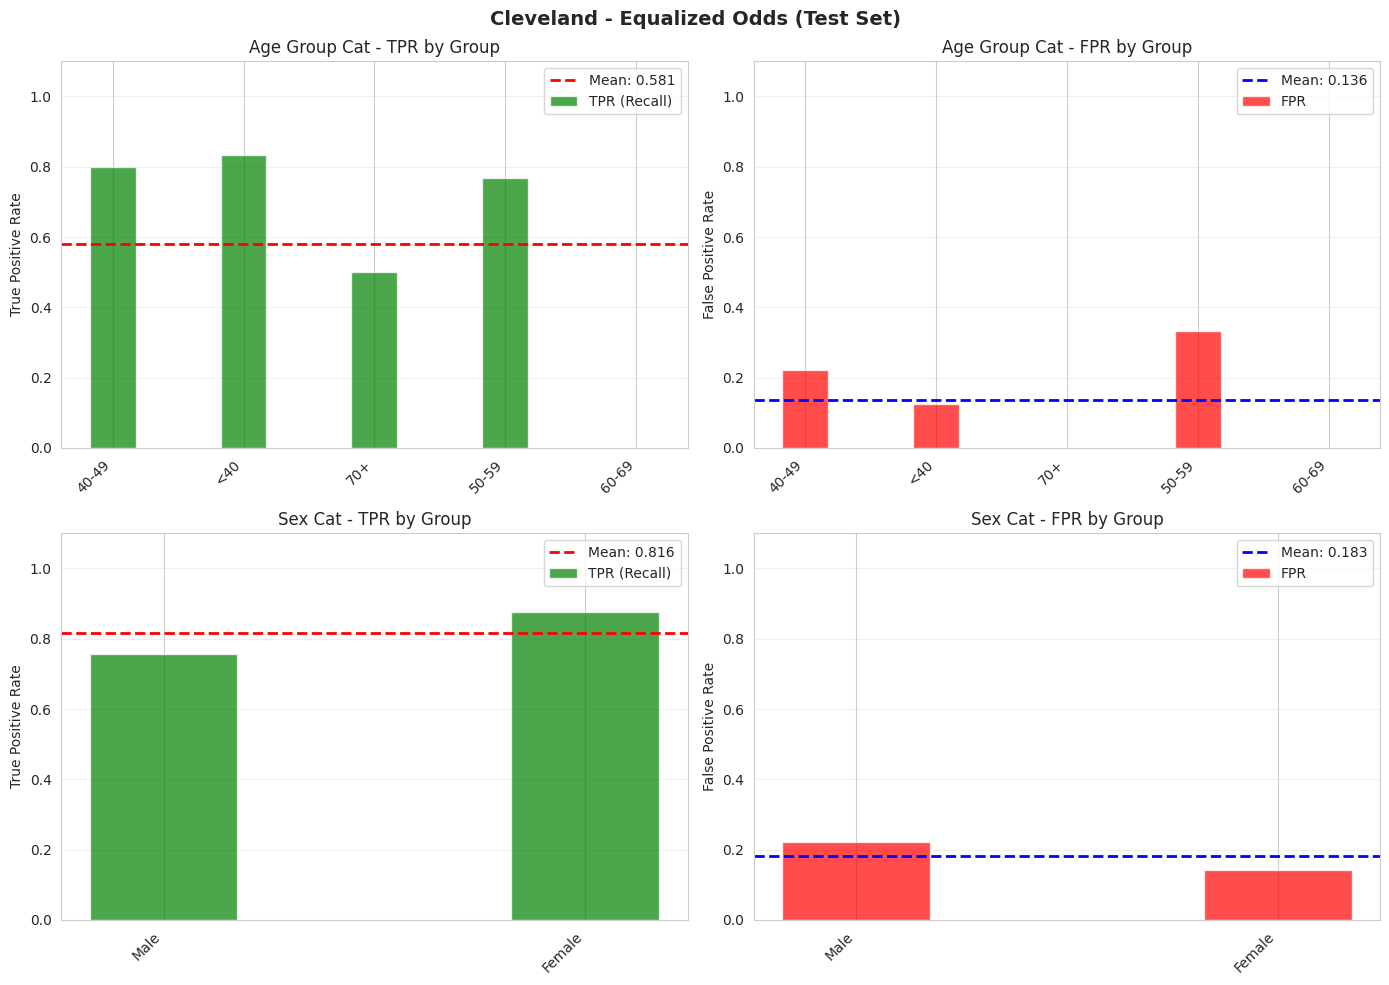

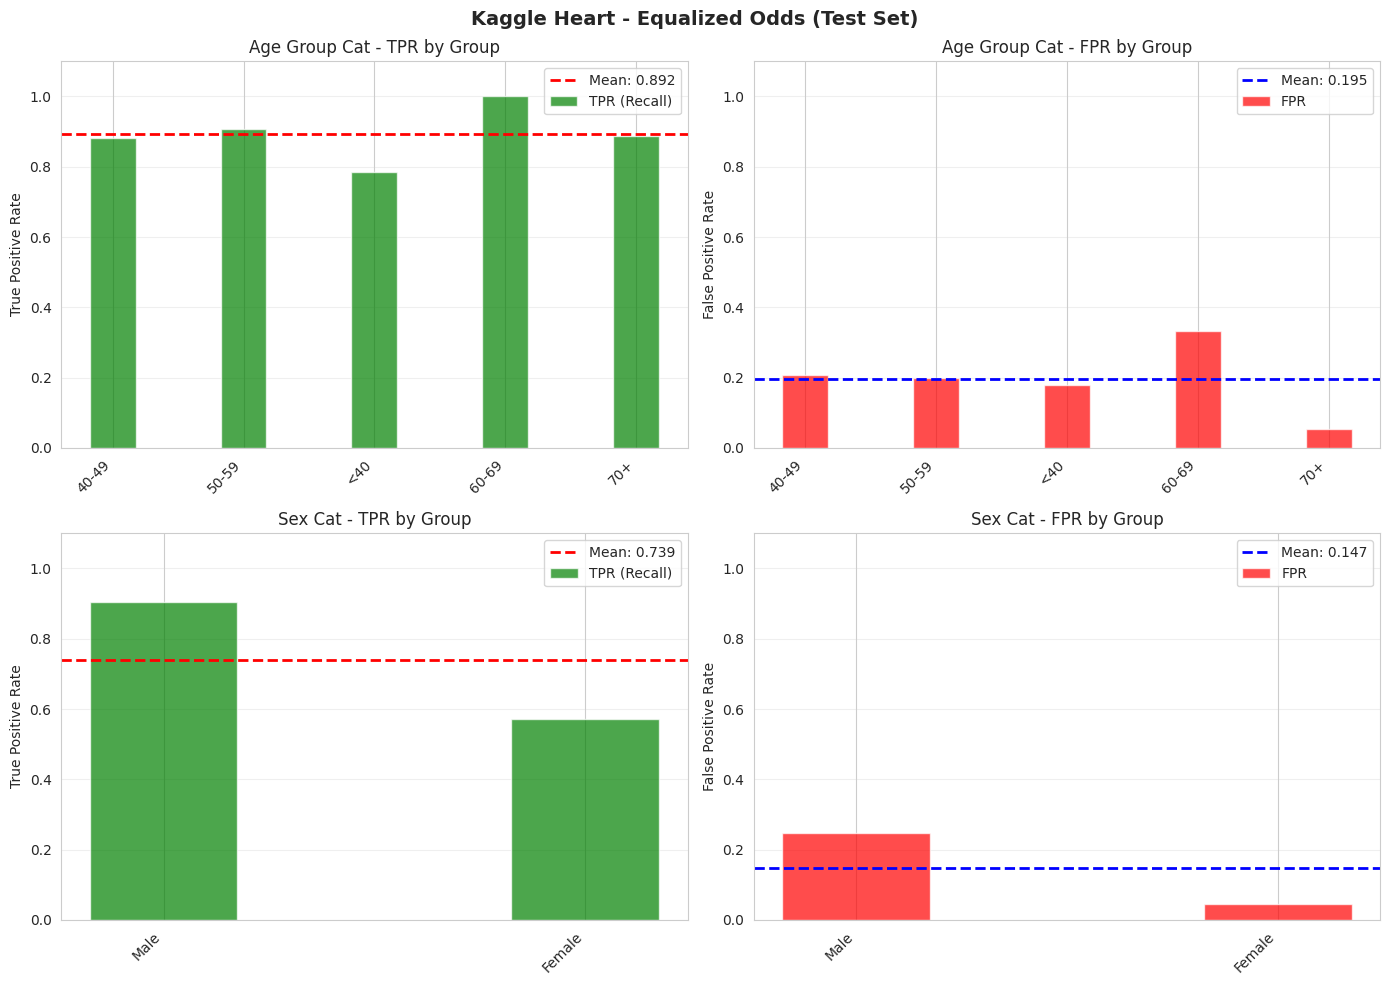

In [12]:
# Use the reusable plotting function
plot_equalized_odds_details(cleveland_fairness, 'Cleveland')
plot_equalized_odds_details(kaggle_fairness, 'Kaggle Heart')
plt.show()

### Calibration Analysis

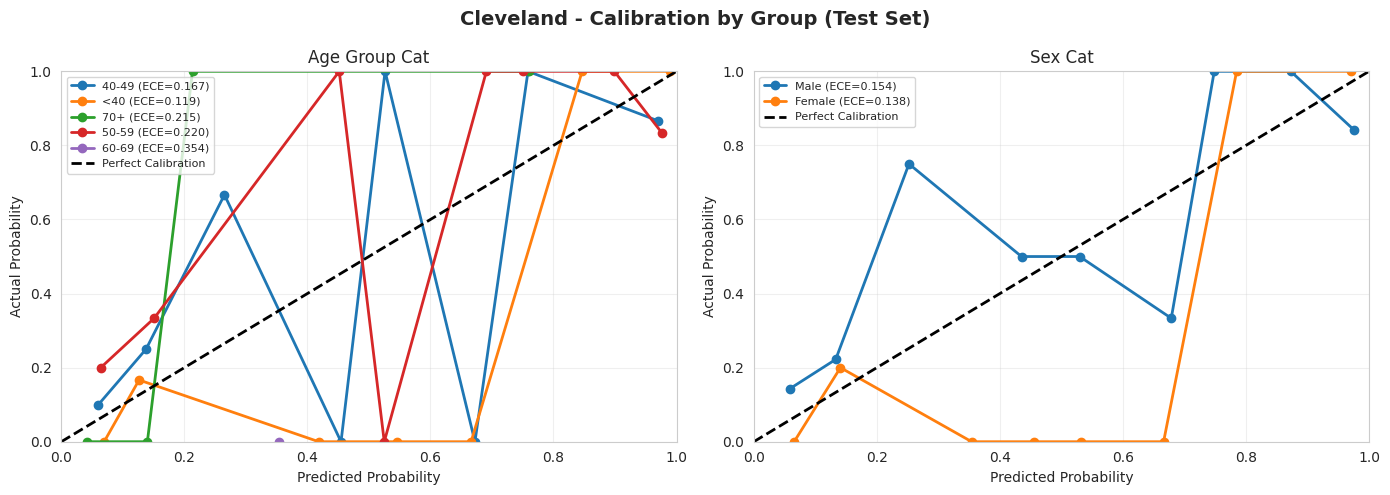

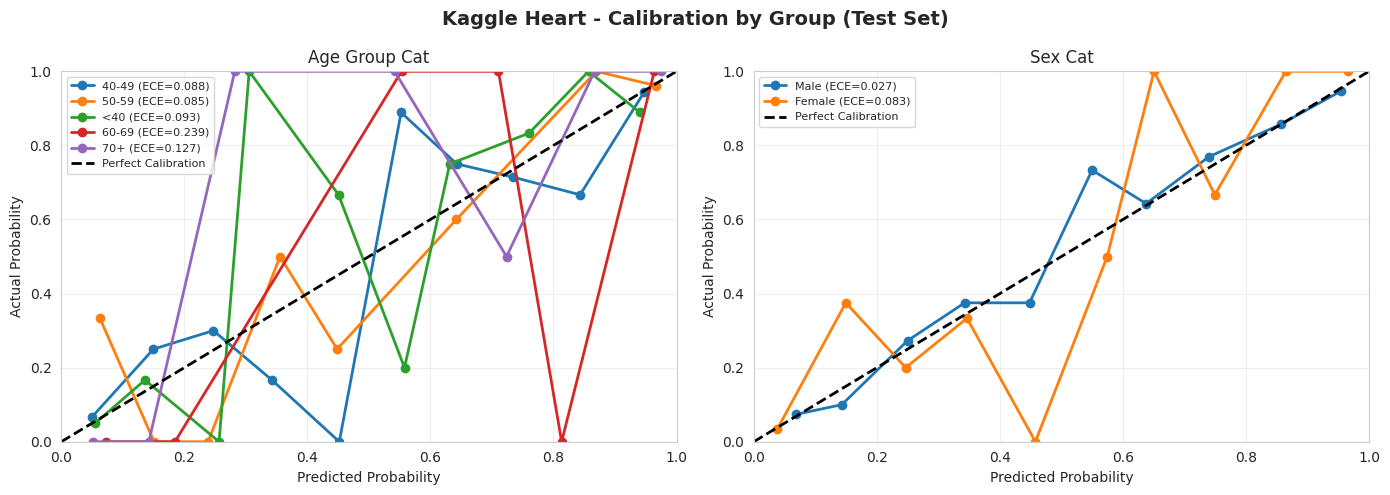

In [13]:
# Use the reusable plotting function
plot_calibration_by_group(cleveland_fairness, 'Cleveland')
plot_calibration_by_group(kaggle_fairness, 'Kaggle Heart')
plt.show()

## 5. Complete Pipeline Fairness Summary

Compare fairness across all stages: Pre-processing → Post-processing

In [14]:
def create_pipeline_fairness_summary(dataset_name, pre_profile, post_fairness):
    """Create summary comparing pre and post-processing fairness."""
    summary_data = []
    
    # Age group
    pre_age_diff = pre_profile['label_imbalance_by_group']['age_group']['statistical_parity_difference']['max_difference']
    post_age_diff = post_fairness['test_metrics']['group_fairness']['age_group_cat']['demographic_parity']['max_difference']
    
    summary_data.append({
        'Dataset': dataset_name,
        'Sensitive Attribute': 'Age Group',
        'Pre-Processing': f"{pre_age_diff:.2%}",
        'Post-Processing': f"{post_age_diff:.2%}",
        'Change': f"{(post_age_diff - pre_age_diff):.2%}"
    })
    
    # Sex
    pre_sex_diff = pre_profile['label_imbalance_by_group']['sex']['statistical_parity_difference']['max_difference']
    post_sex_diff = post_fairness['test_metrics']['group_fairness']['sex_cat']['demographic_parity']['max_difference']
    
    summary_data.append({
        'Dataset': dataset_name,
        'Sensitive Attribute': 'Sex',
        'Pre-Processing': f"{pre_sex_diff:.2%}",
        'Post-Processing': f"{post_sex_diff:.2%}",
        'Change': f"{(post_sex_diff - pre_sex_diff):.2%}"
    })
    
    return pd.DataFrame(summary_data)

# Create summaries
cleveland_pipeline = create_pipeline_fairness_summary('Cleveland', cleveland_profile, cleveland_fairness)
kaggle_pipeline = create_pipeline_fairness_summary('Kaggle Heart', kaggle_profile, kaggle_fairness)

pipeline_summary = pd.concat([cleveland_pipeline, kaggle_pipeline], ignore_index=True)

print("\nPipeline Fairness Summary (Demographic Parity):")
print("="*80)
print(pipeline_summary.to_string(index=False))


Pipeline Fairness Summary (Demographic Parity):
     Dataset Sensitive Attribute Pre-Processing Post-Processing  Change
   Cleveland           Age Group         42.24%          59.09%  16.85%
   Cleveland                 Sex         29.68%          17.18% -12.50%
Kaggle Heart           Age Group         39.20%          42.86%   3.66%
Kaggle Heart                 Sex         37.27%          48.67%  11.40%


### Visualize Pipeline Fairness Evolution

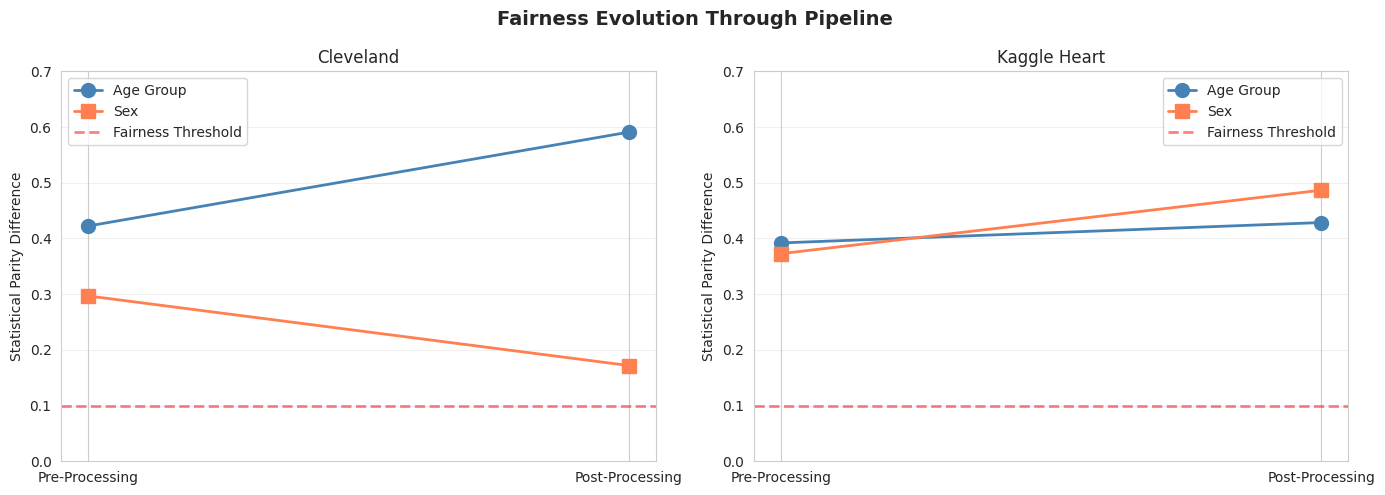

In [15]:
# Use the reusable plotting function
pre_profiles = {
    'cleveland': cleveland_profile,
    'kaggle': kaggle_profile
}

post_fairness = {
    'cleveland': cleveland_fairness,
    'kaggle': kaggle_fairness
}

plot_fairness_evolution(pre_profiles, post_fairness, 
                        dataset_names=['Cleveland', 'Kaggle Heart'])
plt.show()

## 6. Key Findings & Conclusions

### Major Observations:

1. **Pre-Processing Bias**: Both datasets exhibit significant statistical parity violations (29-59%) before any modeling

2. **Bias Persistence**: Fairness violations carry through the pipeline from raw data to predictions

3. **Age Group Disparity**: Most severe fairness violations occur across age groups (up to 60% difference)

4. **Sex-based Disparity**: Moderate but consistent violations (17-49% difference)

5. **Calibration Issues**: Models show poor calibration across groups (ECE differences up to 23.5%)

6. **TPR Inequality**: Equal opportunity violations are severe - some groups have 0-100% lower recall

### Recommendations:

- **Bias Mitigation**: Apply pre-processing (reweighting, resampling) or in-processing (fairness constraints) techniques
- **Threshold Optimization**: Use group-specific decision thresholds to improve equalized odds
- **Additional Data**: Collect more samples from underrepresented groups
- **Feature Engineering**: Investigate and potentially remove features that encode protected attributes
- **Post-processing**: Apply calibration and prediction adjustment methods

## Summary Statistics Table

In [16]:
# Create comprehensive summary
summary_stats = []

for dataset_name, results in training_results.items():
    test_perf = results['test_metrics']
    
    if dataset_name == 'cleveland':
        fairness = cleveland_fairness
        profile = cleveland_profile
    else:
        fairness = kaggle_fairness
        profile = kaggle_profile
    
    age_dp = fairness['test_metrics']['group_fairness']['age_group_cat']['demographic_parity']['max_difference']
    sex_dp = fairness['test_metrics']['group_fairness']['sex_cat']['demographic_parity']['max_difference']
    
    summary_stats.append({
        'Dataset': dataset_name.replace('_', ' ').title(),
        'Samples': results['n_train'] + results['n_test'],
        'Test Accuracy': f"{test_perf['accuracy']:.3f}",
        'AUC-ROC': f"{test_perf['auc_roc']:.3f}",
        'Age DP Violation': f"{age_dp:.2%}",
        'Sex DP Violation': f"{sex_dp:.2%}",
        'Overall Fair': '✗' if (age_dp > 0.1 or sex_dp > 0.1) else '✓'
    })

summary_df = pd.DataFrame(summary_stats)
print("\nFinal Pipeline Summary:")
print("="*100)
print(summary_df.to_string(index=False))


Final Pipeline Summary:
     Dataset  Samples Test Accuracy AUC-ROC Age DP Violation Sex DP Violation Overall Fair
   Cleveland      295         0.798   0.886           59.09%           17.18%            ✗
Kaggle Heart      917         0.851   0.913           42.86%           48.67%            ✗
